# 06_1. Python Bermudan Swaption Pricing

This companion notebook keeps the Bermudan topic but removes all external comparison machinery. The focus is purely
on the Python pricing methods, their diagnostics, and the difference between a regression-based and a deterministic
backward solver on the same synthetic trade.

**Purpose**
- price one Bermudan swaption with Python-only methods
- compare LSMC and backward induction on a shared setup
- inspect exercise diagnostics directly from the Python results

**What you will learn**
- how to define a Bermudan swaption with array-based leg data
- how the two Python pricing methods compare on one trade
- what the exercise diagnostics say about the option profile


In [1]:
from pathlib import Path
import os
import sys

def _pythonorerunner_root(candidate: Path) -> bool:
    return (
        (candidate / "notebook_series" / "series_helpers.py").exists()
        and ((candidate / "pythonore").exists() or (candidate / "src" / "pythonore").exists())
    )

def _engine_root(candidate: Path) -> bool:
    return (candidate / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists()

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if _pythonorerunner_root(candidate) or _engine_root(candidate):
            return candidate
    repo_hint = Path("/Users/gordonlee/Documents/Engine")
    if _engine_root(repo_hint):
        return repo_hint
    standalone_hint = Path("/Users/gordonlee/Documents/PythonOreRunner")
    if _pythonorerunner_root(standalone_hint):
        return standalone_hint
    raise RuntimeError("Could not locate the notebook repo root from the current notebook working directory")

REPO_ROOT = _find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "notebook_series" if _pythonorerunner_root(REPO_ROOT) else REPO_ROOT / "Tools" / "PythonOreRunner" / "notebook_series"
for path in (NOTEBOOK_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import series_helpers as nh

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

repo = nh.bootstrap_notebook_env(REPO_ROOT)
nh.apply_plot_style()
print(repo)


/Users/gordonlee/Documents/PythonOreRunner


In [2]:
import time

from py_ore_tools.lgm import LGM1F, LGMParams, simulate_lgm_measure
from py_ore_tools.lgm_ir_options import BermudanSwaptionDef, bermudan_backward_price, bermudan_lsmc_result
from py_ore_tools.irs_xva_utils import build_discount_curve_from_zero_rate_pairs

params = LGMParams(
    alpha_times=(1.0, 2.0, 4.0),
    alpha_values=(0.010, 0.012, 0.015, 0.013),
    kappa_times=(2.0,),
    kappa_values=(0.035, 0.028),
    shift=0.0,
    scaling=1.0,
)
model = LGM1F(params)
p0_disc = build_discount_curve_from_zero_rate_pairs([(0.0, 0.028), (10.0, 0.031)])
p0_fwd = build_discount_curve_from_zero_rate_pairs([(0.0, 0.029), (10.0, 0.032)])

fixed_start = np.array([1.0, 2.0, 3.0, 4.0], dtype=float)
fixed_end = np.array([2.0, 3.0, 4.0, 5.0], dtype=float)
fixed_pay = fixed_end.copy()
float_start = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5], dtype=float)
float_end = float_start + 0.5
legs = {
    "fixed_start_time": fixed_start,
    "fixed_end_time": fixed_end,
    "fixed_pay_time": fixed_pay,
    "fixed_accrual": np.ones_like(fixed_pay),
    "fixed_rate": np.full_like(fixed_pay, 0.032),
    "fixed_notional": np.full_like(fixed_pay, 10_000_000.0),
    "fixed_sign": np.full_like(fixed_pay, -1.0),
    "fixed_amount": np.full_like(fixed_pay, -320_000.0),
    "float_pay_time": float_end,
    "float_start_time": float_start,
    "float_end_time": float_end,
    "float_accrual": np.full_like(float_start, 0.5),
    "float_notional": np.full_like(float_start, 10_000_000.0),
    "float_sign": np.full_like(float_start, 1.0),
    "float_spread": np.zeros_like(float_start),
    "float_coupon": np.zeros_like(float_start),
}
berm = BermudanSwaptionDef(
    trade_id="BERM_PY_ONLY",
    exercise_times=np.array([1.0, 2.0, 3.0], dtype=float),
    underlying_legs=legs,
    exercise_sign=1.0,
)
times = np.linspace(0.0, 5.0, 21)
x_paths = simulate_lgm_measure(model, times, n_paths=4096, rng=np.random.default_rng(42))

t0 = time.perf_counter()
lsmc = bermudan_lsmc_result(model, p0_disc, p0_fwd, berm, times, x_paths, basis_degree=2, itm_only=True)
lsmc_elapsed = time.perf_counter() - t0
t0 = time.perf_counter()
backward = bermudan_backward_price(model, p0_disc, p0_fwd, berm, n_grid=121, quadrature_order=21)
backward_elapsed = time.perf_counter() - t0

summary = pd.DataFrame(
    [
        {"method": "py_lsmc", "price": float(np.mean(lsmc.npv_paths[0, :])), "elapsed_sec": lsmc_elapsed},
        {"method": "py_backward", "price": float(backward.price), "elapsed_sec": backward_elapsed},
    ]
)
summary["delta_vs_backward"] = summary["price"] - float(backward.price)
display(summary)


,method,price,elapsed_sec,delta_vs_backward
0,py_lsmc,195801.550646,0.023555,4342.088748
1,py_backward,191459.461899,0.003222,0.000000


## Trade setup

The underlying trade is deliberately explicit: fixed-leg arrays, floating-leg arrays, and exercise times are all in
the notebook. That keeps the pricing problem inspectable as a pure Python object.


In [3]:
leg_rows = pd.DataFrame(
    {
        "fixed_start_time": pd.Series(legs["fixed_start_time"]),
        "fixed_end_time": pd.Series(legs["fixed_end_time"]),
        "fixed_pay_time": pd.Series(legs["fixed_pay_time"]),
        "fixed_rate": pd.Series(legs["fixed_rate"]),
        "float_start_time": pd.Series(legs["float_start_time"]),
        "float_end_time": pd.Series(legs["float_end_time"]),
    }
)
display(leg_rows)
display(nh.lgm_params_frame(params))


,fixed_start_time,fixed_end_time,fixed_pay_time,fixed_rate,float_start_time,float_end_time
0,1.0,2.0,2.0,0.032,1.0,1.5
1,2.0,3.0,3.0,0.032,1.5,2.0
2,3.0,4.0,4.0,0.032,2.0,2.5
3,4.0,5.0,5.0,0.032,2.5,3.0
4,NaN,NaN,NaN,NaN,3.0,3.5
5,NaN,NaN,NaN,NaN,3.5,4.0
6,NaN,NaN,NaN,NaN,4.0,4.5
7,NaN,NaN,NaN,NaN,4.5,5.0


,alpha_time,alpha_value,kappa_time,kappa_value
0,1.0,0.010,2.0,0.035
1,2.0,0.012,terminal,0.028
2,4.0,0.015,NaN,NaN
3,terminal,0.013,NaN,NaN


## Price and runtime comparison

The method comparison here is internal to the Python stack: stochastic regression against deterministic backward induction.
On a compact synthetic trade like this, a material gap is not surprising. The value of the notebook is that both
methods are inspectable from the same trade definition and diagnostics.


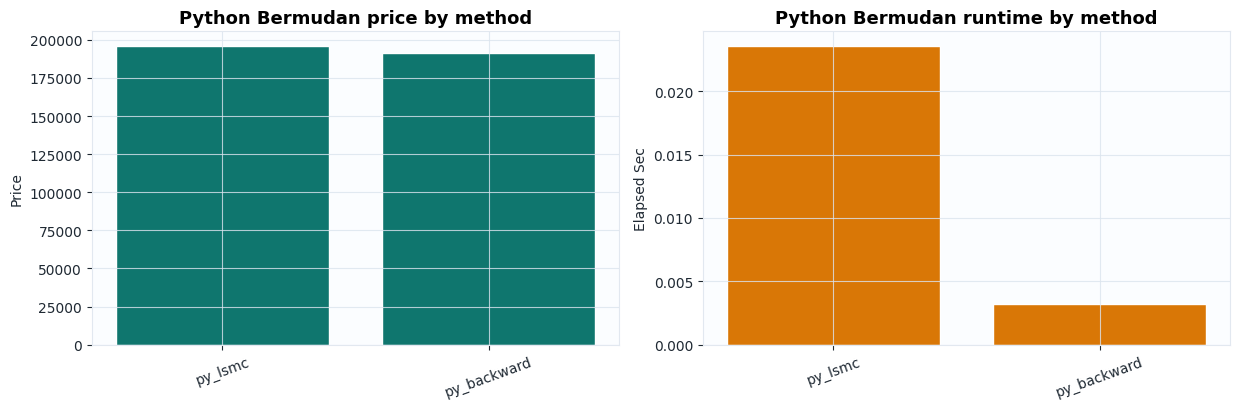

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
nh.plot_bar_frame(summary, "method", "price", title="Python Bermudan price by method", color=nh.PALETTE["teal"], ax=axes[0])
nh.plot_bar_frame(summary, "method", "elapsed_sec", title="Python Bermudan runtime by method", color=nh.PALETTE["gold"], ax=axes[1])
plt.tight_layout()
plt.show()
plt.close(fig)


,method,time,intrinsic_mean,continuation_mean,exercise_probability,boundary_state
0,py_backward,1.0,127104.399568,176155.876910,0.197663,0.008500
1,py_backward,2.0,162523.802893,136858.368245,0.363169,0.005467
2,py_backward,3.0,541015.894399,0.000000,0.504132,-0.001083
3,py_lsmc,1.0,122659.506202,193298.895517,0.173096,0.009045
4,py_lsmc,2.0,118265.107488,105626.406376,0.273989,0.006378
5,py_lsmc,3.0,65298.451447,0.000000,0.330622,-0.001619


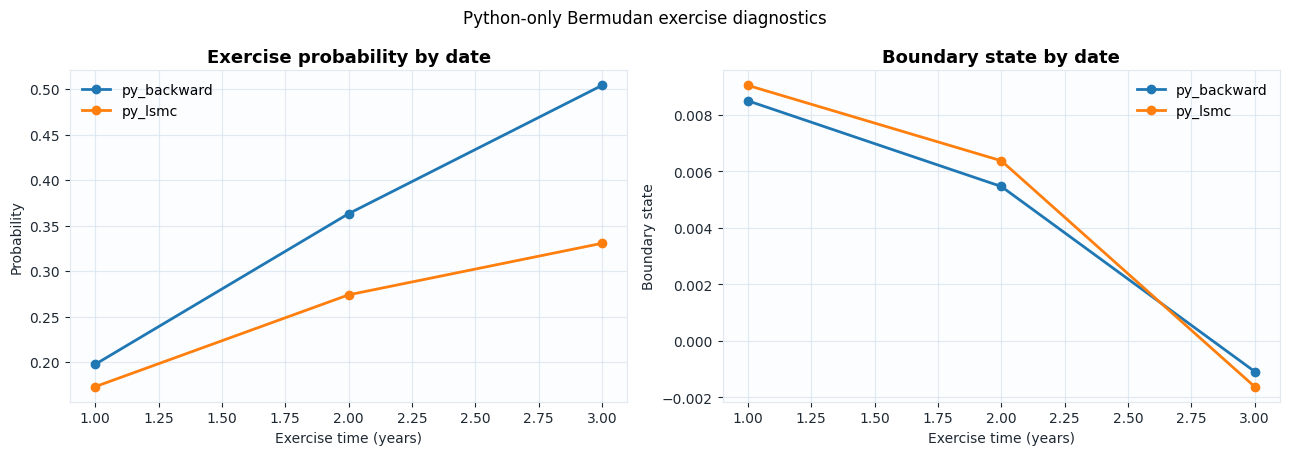

In [5]:
diag_rows = []
for diag in lsmc.diagnostics:
    diag_rows.append(
        {
            "method": "py_lsmc",
            "time": float(diag.time),
            "intrinsic_mean": float(diag.intrinsic_mean),
            "continuation_mean": float(diag.continuation_mean),
            "exercise_probability": float(diag.exercise_probability),
            "boundary_state": np.nan if diag.boundary_state is None else float(diag.boundary_state),
        }
    )
for diag in backward.diagnostics:
    diag_rows.append(
        {
            "method": "py_backward",
            "time": float(diag.time),
            "intrinsic_mean": float(diag.intrinsic_mean),
            "continuation_mean": float(diag.continuation_mean),
            "exercise_probability": float(diag.exercise_probability),
            "boundary_state": np.nan if diag.boundary_state is None else float(diag.boundary_state),
        }
    )
diag_df = pd.DataFrame(diag_rows).sort_values(["method", "time"]).reset_index(drop=True)
display(diag_df)
nh.plot_bermudan_exercise_diagnostics(diag_df, title="Python-only Bermudan exercise diagnostics")


The exercise chart is the main sanity check. It shows whether the two methods agree on roughly when the option is
alive and where the exercise boundary sits in the state variable.


,bucket,count
0,exercise_1Y,709
1,exercise_2Y,928
2,exercise_3Y,813
3,never_exercised,1646


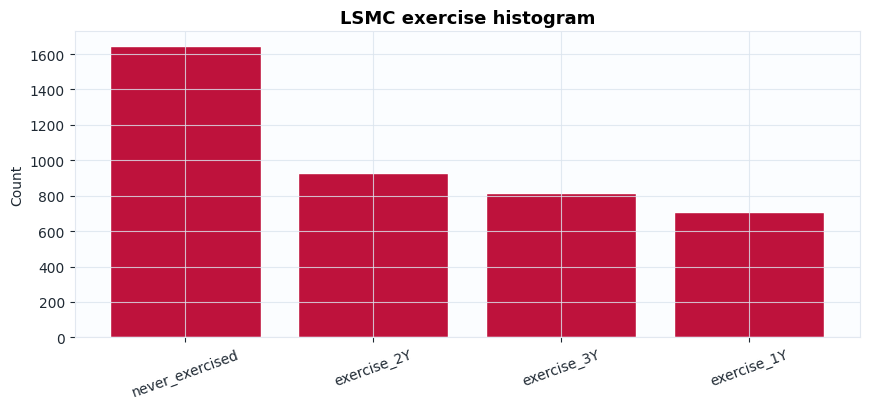

In [6]:
exercise_hist = pd.DataFrame(
    [
        {"bucket": "exercise_1Y", "count": int(np.sum(lsmc.exercise_indices == np.searchsorted(times, 1.0)))},
        {"bucket": "exercise_2Y", "count": int(np.sum(lsmc.exercise_indices == np.searchsorted(times, 2.0)))},
        {"bucket": "exercise_3Y", "count": int(np.sum(lsmc.exercise_indices == np.searchsorted(times, 3.0)))},
        {"bucket": "never_exercised", "count": int(np.sum(lsmc.exercise_indices < 0))},
    ]
)
display(exercise_hist)

fig, ax = plt.subplots(figsize=(8.8, 4.2))
nh.plot_bar_frame(exercise_hist, "bucket", "count", title="LSMC exercise histogram", color=nh.PALETTE["rose"], ax=ax)
plt.tight_layout()
plt.show()
plt.close(fig)


## Key takeaways

- Bermudan pricing can be demonstrated cleanly with Python-only trade arrays and curves.
- The backward solver and the LSMC solver are complementary methods, not interchangeable black boxes.
- Exercise diagnostics matter as much as the headline price when checking method behaviour.
